# Notebook 5: Non-IB Customer — Anomaly Detection & Risk Flagging

**G'CONTEST 2026 — Phát hiện hành vi bất thường nhóm khách hàng Non-IB**

Đáp ứng yêu cầu đề bài:
> *"Hệ thống cần đưa ra lý do cụ thể cho các giao dịch hoặc hành vi bị đánh dấu bất thường."*

Phương pháp:
1. **Isolation Forest** — ML-based anomaly detection
2. **Local Outlier Factor (LOF)** — Density-based
3. **Rule-based Flags** — Business logic cho Explainable AI

**Input:** `output/nonib_master.parquet`
**Output:** `output/nonib_anomalies.csv` + giải thích cho mỗi anomaly

In [1]:
# ============================================================
# IMPORTS
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100})
sns.set_style('whitegrid')

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'Cluster_nonIB':
    PROJECT_DIR = PROJECT_DIR.parent

CLUSTER_DIR = PROJECT_DIR / 'Cluster_nonIB'
OUTPUT_DIR = CLUSTER_DIR / 'output'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Ready.')

Ready.


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_parquet(OUTPUT_DIR / 'nonib_master.parquet')

# Only active customers (with products)
df_active = df[df['IS_DORMANT'] == 0].copy()
print(f'Active Non-IB customers: {len(df_active):,}')

# Features for anomaly detection
ANOMALY_FEATURES = [
    'AGE', 'TENURE_DAYS',
    'CA_BALANCE_MEAN', 'CA_BALANCE_STD', 'CA_BALANCE_TREND',
    'TD_BALANCE_MEAN', 'TD_BALANCE_STD', 'TD_BALANCE_TREND',
    'LOAN_AMOUNT_MEAN', 'LOAN_TREND', 'LOAN_COUNT_MAX',
    'CREDITCARD_MAX', 'DEBITCARD_MAX',
    'PRODUCT_COUNT', 'NET_WORTH_PROXY',
    'TOTAL_TRANS_COUNT', 'External_Outflow_Amount', 'Internal_Engagement_Amount',
]

X = df_active[ANOMALY_FEATURES].copy()

# Log-transform monetary features
for col in ['CA_BALANCE_MEAN', 'CA_BALANCE_STD', 'TD_BALANCE_MEAN',
            'TD_BALANCE_STD', 'LOAN_AMOUNT_MEAN',
            'External_Outflow_Amount', 'Internal_Engagement_Amount']:
    X[col] = np.log1p(X[col].clip(lower=0))

# Signed log for NET_WORTH_PROXY
nw = X['NET_WORTH_PROXY']
X['NET_WORTH_PROXY'] = np.sign(nw) * np.log1p(np.abs(nw))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))

print(f'Feature matrix: {X_scaled.shape}')

Active Non-IB customers: 102,430
Feature matrix: (102430, 18)


---
## 1. Isolation Forest

In [3]:
# ----------------------------------------------------------
# Isolation Forest — contamination ~3%
# ----------------------------------------------------------
CONTAMINATION = 0.03  # Expect ~3% anomalies

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1,
)

df_active['IF_LABEL'] = iso_forest.fit_predict(X_scaled)  # 1=normal, -1=anomaly
df_active['IF_SCORE'] = iso_forest.decision_function(X_scaled)  # lower = more anomalous

n_anomaly_if = (df_active['IF_LABEL'] == -1).sum()
print(f'Isolation Forest anomalies: {n_anomaly_if:,} ({n_anomaly_if/len(df_active)*100:.2f}%)')
print(f'Score range: [{df_active["IF_SCORE"].min():.4f}, {df_active["IF_SCORE"].max():.4f}]')

Isolation Forest anomalies: 3,073 (3.00%)
Score range: [-0.1588, 0.1818]


---
## 2. Local Outlier Factor (LOF)

In [4]:
# ----------------------------------------------------------
# LOF
# ----------------------------------------------------------
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION,
    n_jobs=-1,
)

df_active['LOF_LABEL'] = lof.fit_predict(X_scaled)  # 1=normal, -1=anomaly
df_active['LOF_SCORE'] = lof.negative_outlier_factor_  # more negative = more anomalous

n_anomaly_lof = (df_active['LOF_LABEL'] == -1).sum()
print(f'LOF anomalies: {n_anomaly_lof:,} ({n_anomaly_lof/len(df_active)*100:.2f}%)')

# Consensus: both methods agree
df_active['IS_ANOMALY_CONSENSUS'] = (
    (df_active['IF_LABEL'] == -1) & (df_active['LOF_LABEL'] == -1)
).astype('int8')

n_consensus = df_active['IS_ANOMALY_CONSENSUS'].sum()
print(f'\nConsensus anomalies (both IF + LOF): {n_consensus:,} ({n_consensus/len(df_active)*100:.2f}%)')

LOF anomalies: 3,073 (3.00%)

Consensus anomalies (both IF + LOF): 606 (0.59%)


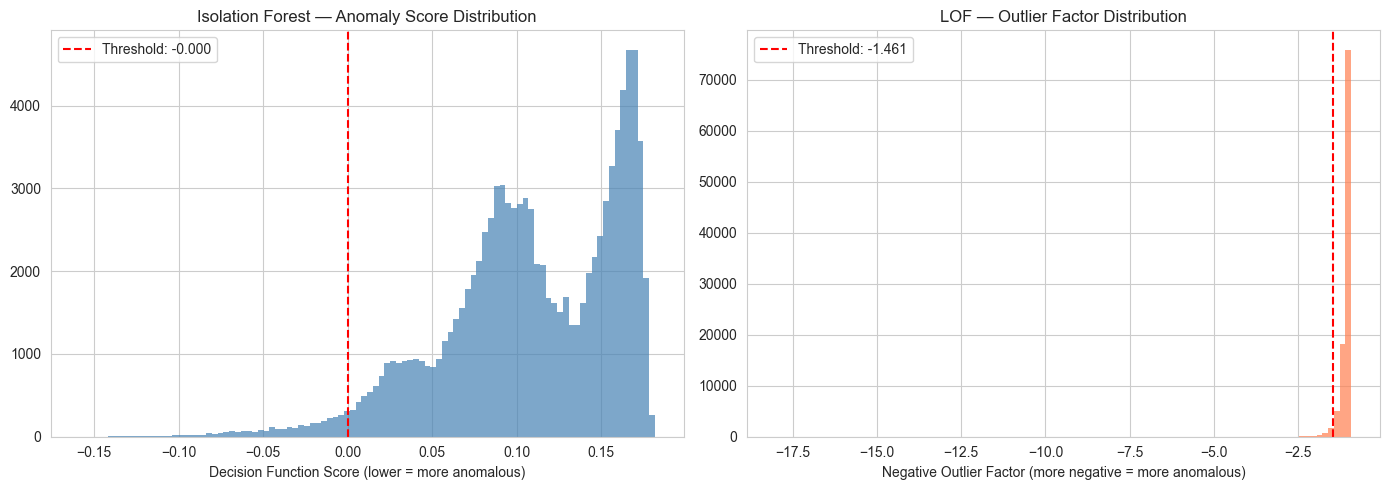

In [5]:
# Visualization: Anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IF score
axes[0].hist(df_active['IF_SCORE'], bins=100, color='steelblue', alpha=0.7, edgecolor='none')
threshold_if = df_active.loc[df_active['IF_LABEL'] == -1, 'IF_SCORE'].max()
axes[0].axvline(threshold_if, color='red', linestyle='--', label=f'Threshold: {threshold_if:.3f}')
axes[0].set_title('Isolation Forest — Anomaly Score Distribution')
axes[0].set_xlabel('Decision Function Score (lower = more anomalous)')
axes[0].legend()

# LOF score
axes[1].hist(df_active['LOF_SCORE'], bins=100, color='coral', alpha=0.7, edgecolor='none')
threshold_lof = df_active.loc[df_active['LOF_LABEL'] == -1, 'LOF_SCORE'].max()
axes[1].axvline(threshold_lof, color='red', linestyle='--', label=f'Threshold: {threshold_lof:.3f}')
axes[1].set_title('LOF — Outlier Factor Distribution')
axes[1].set_xlabel('Negative Outlier Factor (more negative = more anomalous)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Rule-Based Flags (Explainable AI)

Tạo lý do giải thích cho mỗi anomaly — **đây là phần quan trọng nhất cho điểm thi.**

In [6]:
# ----------------------------------------------------------
# Rule-based anomaly flags with human-readable explanations
# ----------------------------------------------------------

# Compute thresholds from active customer statistics
ca_trend_p5 = df_active['CA_BALANCE_TREND'].quantile(0.05)
loan_trend_p95 = df_active['LOAN_TREND'].quantile(0.95)
loan_amount_p95 = df_active['LOAN_AMOUNT_MEAN'].quantile(0.95)
ca_std_p95 = df_active['CA_BALANCE_STD'].quantile(0.95)
loan_count_p99 = df_active['LOAN_COUNT_MAX'].quantile(0.99)

print('Thresholds:')
print(f'  CA trend P5 (sharp decline): {ca_trend_p5:,.0f}')
print(f'  Loan trend P95 (sharp increase): {loan_trend_p95:,.0f}')
print(f'  Loan amount P95: {loan_amount_p95:,.0f}')
print(f'  CA std P95 (high volatility): {ca_std_p95:,.0f}')
print(f'  Loan count P99: {loan_count_p99}')

# Apply rules
reasons = []

for idx, row in df_active.iterrows():
    flags = []

    # Rule 1: Sharp CA balance decline
    if row['CA_BALANCE_TREND'] < ca_trend_p5 and row['CA_BALANCE_MEAN'] > 0:
        flags.append(
            'Dòng tiền ra bất thường: Số dư TKTT giảm mạnh '
            f'(xu hướng: {row["CA_BALANCE_TREND"]:,.0f}/tháng)'
        )

    # Rule 2: Loan debt increasing sharply
    if row['LOAN_TREND'] > loan_trend_p95 and row['LOAN_AMOUNT_MEAN'] > loan_amount_p95:
        flags.append(
            'Dư nợ tăng đột biến: Khối lượng vay tăng nhanh '
            f'({row["LOAN_TREND"]:,.0f}/tháng), dư nợ hiện tại: {row["LOAN_AMOUNT_MEAN"]:,.0f} VND'
        )

    # Rule 3: High CA volatility
    if row['CA_BALANCE_STD'] > ca_std_p95 and row['CA_BALANCE_MEAN'] > 0:
        flags.append(
            'Biến động số dư bất thường: Tài khoản thanh toán có độ biến động rất cao '
            f'(std: {row["CA_BALANCE_STD"]:,.0f} VND)'
        )

    # Rule 4: Ghost account (long tenure, no products used recently)
    if row['TENURE_DAYS'] > 300 and row['MONTHS_WITH_DEPOSIT'] <= 1 and row['PRODUCT_COUNT'] <= 1:
        flags.append(
            'Tài khoản "ma": Khách hàng tenure dài '
            f'({row["TENURE_DAYS"]} ngày) nhưng gần như không sử dụng sản phẩm'
        )

    # Rule 5: Excessive number of loans
    if row['LOAN_COUNT_MAX'] > loan_count_p99:
        flags.append(
            f'Số lượng khoản vay bất thường: {int(row["LOAN_COUNT_MAX"])} khoản vay đồng thời'
        )

    # Rule 6: Large negative net worth
    if row['NET_WORTH_PROXY'] < 0 and abs(row['NET_WORTH_PROXY']) > row['LOAN_AMOUNT_MEAN'] * 0.5:
        if row['LOAN_AMOUNT_MEAN'] > loan_amount_p95:
            flags.append(
                'Giá trị ròng âm lớn: Dư nợ vượt xa tổng tiền gửi, '
                f'net worth: {row["NET_WORTH_PROXY"]:,.0f} VND'
            )

    if flags:
        reasons.append({
            'CUSTOMER_NUMBER': row['CUSTOMER_NUMBER'],
            'N_FLAGS': len(flags),
            'REASONS': ' | '.join(flags),
        })

rule_flags_df = pd.DataFrame(reasons)
print(f'\nRule-based anomalies: {len(rule_flags_df):,} customers flagged')
print(f'Flag distribution:')
if len(rule_flags_df) > 0:
    print(rule_flags_df['N_FLAGS'].value_counts().sort_index())

Thresholds:
  CA trend P5 (sharp decline): -350,881
  Loan trend P95 (sharp increase): 0
  Loan amount P95: 776,250,000
  CA std P95 (high volatility): 3,803,285
  Loan count P99: 2.0

Rule-based anomalies: 13,144 customers flagged
Flag distribution:
N_FLAGS
1    9859
2    2549
3     623
4      88
5      25
Name: count, dtype: int64


In [7]:
# Show sample flagged customers
if len(rule_flags_df) > 0:
    print('Sample flagged customers (top 10 by number of flags):')
    top_flagged = rule_flags_df.nlargest(10, 'N_FLAGS')
    for _, row in top_flagged.iterrows():
        print(f'\n  KH #{int(row["CUSTOMER_NUMBER"])} — {row["N_FLAGS"]} flag(s):')
        for reason in row['REASONS'].split(' | '):
            print(f'    ⚠️ {reason}')
else:
    print('No rule-based anomalies detected.')

Sample flagged customers (top 10 by number of flags):

  KH #600599 — 5 flag(s):
    ⚠️ Dòng tiền ra bất thường: Số dư TKTT giảm mạnh (xu hướng: -7,783,491/tháng)
    ⚠️ Dư nợ tăng đột biến: Khối lượng vay tăng nhanh (26,620,846/tháng), dư nợ hiện tại: 2,374,766,833 VND
    ⚠️ Biến động số dư bất thường: Tài khoản thanh toán có độ biến động rất cao (std: 30,155,537 VND)
    ⚠️ Số lượng khoản vay bất thường: 3 khoản vay đồng thời
    ⚠️ Giá trị ròng âm lớn: Dư nợ vượt xa tổng tiền gửi, net worth: -2,337,338,084 VND

  KH #475339 — 5 flag(s):
    ⚠️ Dòng tiền ra bất thường: Số dư TKTT giảm mạnh (xu hướng: -3,857,450/tháng)
    ⚠️ Dư nợ tăng đột biến: Khối lượng vay tăng nhanh (34,523,810/tháng), dư nợ hiện tại: 812,500,000 VND
    ⚠️ Biến động số dư bất thường: Tài khoản thanh toán có độ biến động rất cao (std: 16,751,006 VND)
    ⚠️ Số lượng khoản vay bất thường: 3 khoản vay đồng thời
    ⚠️ Giá trị ròng âm lớn: Dư nợ vượt xa tổng tiền gửi, net worth: -805,163,716 VND

  KH #869473 — 5 

---
## 4. Combined Anomaly Score

In [8]:
# ----------------------------------------------------------
# Combine ML-based and Rule-based anomaly detection
# ----------------------------------------------------------

# Merge rule flags
if len(rule_flags_df) > 0:
    rule_flag_ids = set(rule_flags_df['CUSTOMER_NUMBER'])
    df_active['IS_RULE_FLAGGED'] = df_active['CUSTOMER_NUMBER'].isin(rule_flag_ids).astype('int8')
else:
    df_active['IS_RULE_FLAGGED'] = 0

# Combined risk score (0-3)
df_active['RISK_SCORE'] = (
    (df_active['IF_LABEL'] == -1).astype(int) +
    (df_active['LOF_LABEL'] == -1).astype(int) +
    df_active['IS_RULE_FLAGGED'].astype(int)
)

# Risk level
df_active['RISK_LEVEL'] = pd.cut(
    df_active['RISK_SCORE'],
    bins=[-1, 0, 1, 2, 3],
    labels=['Normal', 'Low Risk', 'Medium Risk', 'High Risk']
)

print('Risk Level Distribution:')
risk_counts = df_active['RISK_LEVEL'].value_counts()
for level, count in risk_counts.items():
    print(f'  {level}: {count:,} ({count/len(df_active)*100:.2f}%)')

Risk Level Distribution:
  Normal: 85,725 (83.69%)
  Low Risk: 14,472 (14.13%)
  Medium Risk: 1,881 (1.84%)
  High Risk: 352 (0.34%)


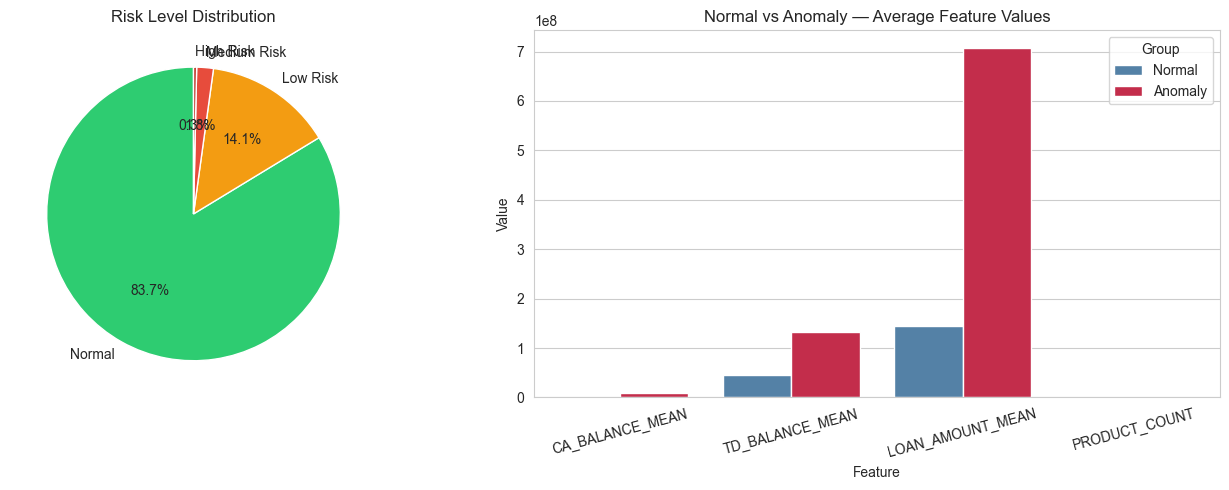

In [9]:
# Visualization: Risk level pie chart + anomaly characteristics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
risk_counts_sorted = df_active['RISK_LEVEL'].value_counts().reindex(
    ['Normal', 'Low Risk', 'Medium Risk', 'High Risk']
).fillna(0)
axes[0].pie(
    risk_counts_sorted.values,
    labels=risk_counts_sorted.index,
    autopct='%1.1f%%',
    colors=colors[:len(risk_counts_sorted)],
    startangle=90
)
axes[0].set_title('Risk Level Distribution')

# Anomalies characteristics: Compare normal vs anomaly on key features
is_anomaly = df_active['RISK_SCORE'] >= 2
compare_cols = ['CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'LOAN_AMOUNT_MEAN', 'PRODUCT_COUNT']
compare_data = pd.DataFrame({
    'Feature': compare_cols * 2,
    'Value': (
        [df_active.loc[~is_anomaly, c].mean() for c in compare_cols] +
        [df_active.loc[is_anomaly, c].mean() for c in compare_cols]
    ),
    'Group': ['Normal'] * len(compare_cols) + ['Anomaly'] * len(compare_cols),
})

sns.barplot(data=compare_data, x='Feature', y='Value', hue='Group',
            ax=axes[1], palette=['steelblue', 'crimson'])
axes[1].set_title('Normal vs Anomaly — Average Feature Values')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Export Anomaly Report

In [10]:
# ----------------------------------------------------------
# Build final anomaly report
# ----------------------------------------------------------

# Filter customers with RISK_SCORE >= 1
anomalies = df_active[df_active['RISK_SCORE'] >= 1][[
    'CUSTOMER_NUMBER', 'AGE', 'TENURE_DAYS', 'PRODUCT_COUNT',
    'CA_BALANCE_MEAN', 'CA_BALANCE_TREND', 'CA_BALANCE_STD',
    'TD_BALANCE_MEAN', 'LOAN_AMOUNT_MEAN', 'LOAN_TREND',
    'NET_WORTH_PROXY', 'IF_SCORE', 'LOF_SCORE',
    'RISK_SCORE', 'RISK_LEVEL',
]].copy()

# Merge rule-based reasons
if len(rule_flags_df) > 0:
    anomalies = anomalies.merge(
        rule_flags_df[['CUSTOMER_NUMBER', 'REASONS']],
        on='CUSTOMER_NUMBER', how='left'
    )
    anomalies['REASONS'] = anomalies['REASONS'].fillna('ML-detected anomaly (no specific rule triggered)')
else:
    anomalies['REASONS'] = 'ML-detected anomaly (no specific rule triggered)'

# Sort by risk
anomalies = anomalies.sort_values('RISK_SCORE', ascending=False)

print(f'Total anomalous customers: {len(anomalies):,}')
print(f'\nRisk breakdown:')
print(anomalies['RISK_LEVEL'].value_counts())

# Save
save_path = OUTPUT_DIR / 'nonib_anomalies.csv'
anomalies.to_csv(save_path, index=False)
print(f'\nSaved: {save_path}')

# Show top 20 highest risk
print('\n\nTop 20 highest risk customers:')
display(anomalies.head(20))

Total anomalous customers: 16,705

Risk breakdown:
RISK_LEVEL
Low Risk       14472
Medium Risk     1881
High Risk        352
Normal             0
Name: count, dtype: int64

Saved: c:\Users\Admin\Desktop\gcon\train_Cluster_nonIB\output\nonib_anomalies.csv


Top 20 highest risk customers:


,CUSTOMER_NUMBER,AGE,TENURE_DAYS,PRODUCT_COUNT,CA_BALANCE_MEAN,CA_BALANCE_TREND,CA_BALANCE_STD,TD_BALANCE_MEAN,LOAN_AMOUNT_MEAN,LOAN_TREND,NET_WORTH_PROXY,IF_SCORE,LOF_SCORE,RISK_SCORE,RISK_LEVEL,REASONS
0,597069,22.146475,356,1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.001531,-1.507058,3,High Risk,"Tài khoản ""ma"": Khách hàng tenure dài (356 ngà..."
467,382668,34.688569,252,3,8.653217e+06,2.310859e+06,7.114269e+06,0.000000e+00,4.676776e+08,-8.538975e+06,-4.590244e+08,-0.025301,-1.665998,3,High Risk,Biến động số dư bất thường: Tài khoản thanh to...
5596,566613,32.826831,342,3,7.476922e+06,1.258555e+06,1.154676e+07,0.000000e+00,7.074427e+08,-2.360057e+07,-6.999657e+08,-0.002659,-1.744574,3,High Risk,Biến động số dư bất thường: Tài khoản thanh to...
954,777638,37.930185,356,1,1.219250e+07,-9.617438e+06,2.745011e+07,0.000000e+00,0.000000e+00,0.000000e+00,1.219250e+07,-0.001772,-1.484921,3,High Risk,Dòng tiền ra bất thường: Số dư TKTT giảm mạnh ...
4947,862125,57.960301,96,3,3.040533e+07,-3.096755e+07,3.316376e+07,3.051821e+08,8.470000e+08,-3.000000e+06,-5.114126e+08,-0.115922,-1.733579,3,High Risk,Dòng tiền ra bất thường: Số dư TKTT giảm mạnh ...
2697,699756,37.409993,282,3,9.046791e+05,8.545766e+05,1.429583e+06,0.000000e+00,9.401539e+08,3.314957e+08,-9.392492e+08,-0.078236,-1.530971,3,High Risk,Dư nợ tăng đột biến: Khối lượng vay tăng nhanh...
1748,349298,35.036277,120,2,1.705620e+07,2.046743e+07,3.411239e+07,7.500000e+08,0.000000e+00,0.000000e+00,7.670562e+08,-0.046407,-1.828742,3,High Risk,Biến động số dư bất thường: Tài khoản thanh to...
1112,336070,49.199179,180,3,2.023339e+07,-4.581546e+06,2.372833e+07,3.353943e+08,0.000000e+00,0.000000e+00,3.556277e+08,-0.071020,-1.522026,3,High Risk,Dòng tiền ra bất thường: Số dư TKTT giảm mạnh ...
5305,720298,40.999316,258,3,1.568785e+07,5.732212e+06,2.097284e+07,3.434301e+08,0.000000e+00,0.000000e+00,3.591180e+08,-0.065997,-1.714380,3,High Risk,Biến động số dư bất thường: Tài khoản thanh to...
7538,130822,53.998631,182,2,6.822478e+07,0.000000e+00,0.000000e+00,0.000000e+00,1.819412e+09,1.339153e+08,-1.751188e+09,-0.008828,-2.001712,3,High Risk,Dư nợ tăng đột biến: Khối lượng vay tăng nhanh...


In [11]:
# ----------------------------------------------------------
# Summary Statistics
# ----------------------------------------------------------
print('=' * 60)
print('ANOMALY DETECTION SUMMARY — NON-IB CUSTOMERS')
print('=' * 60)
print(f'''
Total active Non-IB customers: {len(df_active):,}

Detection Methods:
  Isolation Forest:   {(df_active["IF_LABEL"]==-1).sum():,} anomalies ({(df_active["IF_LABEL"]==-1).mean()*100:.2f}%)
  Local Outlier Factor: {(df_active["LOF_LABEL"]==-1).sum():,} anomalies ({(df_active["LOF_LABEL"]==-1).mean()*100:.2f}%)
  Rule-based Flags:   {df_active["IS_RULE_FLAGGED"].sum():,} flagged ({df_active["IS_RULE_FLAGGED"].mean()*100:.2f}%)

Combined Risk Assessment:
  Normal:      {(df_active["RISK_SCORE"]==0).sum():,}
  Low Risk:    {(df_active["RISK_SCORE"]==1).sum():,}
  Medium Risk: {(df_active["RISK_SCORE"]==2).sum():,}
  High Risk:   {(df_active["RISK_SCORE"]==3).sum():,}

Output: {save_path}
''')

print('\n✅ Notebook 5 complete. Pipeline finished!')
print('\n📊 All outputs saved in ./output/')
print('📈 All figures saved in ./output/figures/')

ANOMALY DETECTION SUMMARY — NON-IB CUSTOMERS

Total active Non-IB customers: 102,430

Detection Methods:
  Isolation Forest:   3,073 anomalies (3.00%)
  Local Outlier Factor: 3,073 anomalies (3.00%)
  Rule-based Flags:   13,144 flagged (12.83%)

Combined Risk Assessment:
  Normal:      85,725
  Low Risk:    14,472
  Medium Risk: 1,881
  High Risk:   352

Output: c:\Users\Admin\Desktop\gcon\train_Cluster_nonIB\output\nonib_anomalies.csv


✅ Notebook 5 complete. Pipeline finished!

📊 All outputs saved in ./output/
📈 All figures saved in ./output/figures/
